# Resolved Concentric Multigroup Diffusion Model

This notebook consumes one resolved OpenMC `group_sweep/group_<N>` export through the backend adapter and cache. It preserves each exported OpenMC cell as a separate diffusion region, uses `D = 1 / (3 Sigma_tr)`, and solves with only the non-`nu` P0 scattering matrix.

The canonical diffusion export must declare `scatter_correction = null`. Newly generated OpenMC MG validation libraries use supplemental P0-corrected consistent scattering tallies from the same continuous-energy run, but those corrected matrices are not diffusion inputs. See [diffusion_mgxs_workflow.md](diffusion_mgxs_workflow.md) for the full contract.

The clean unrodded solve is the stability milestone. The final equivalent-absorber rod scan is exploratory and is not transport-calibrated. SPH and discontinuity factors remain deferred.

In [3]:
from pathlib import Path
from pprint import pprint
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().parent
if not (project_root / "backend").is_dir():
    project_root = Path.cwd()
sys.path.insert(0, str(project_root / "backend"))

from reactor_backend.diffusion import rho_pcm
from reactor_backend.multigroup_diffusion import (
    ConcentricMeshSpacing,
    scan_multigroup_rod_worth_2d,
)
from reactor_backend.multigroup_diffusion_cache import (
    DiffusionCacheSettings,
    prepare_concentric_diffusion_cache,
)
from reactor_backend.openmc_mgxs_adapter import load_concentric_diffusion_input

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. Select, Validate, and Prepare the Export

`MGXS_EXPORT_DIR` selects both `outputs/mgxs_constants.json` and the colocated `reactor_run/model.xml`. Change only the final `group_<N>` component to select another available group structure.

A cache miss builds one CSR spatial matrix per group and solves the clean state synchronously. A cache hit reloads the mesh, material arrays, matrices, and clean result. SuperLU factors remain process-local and are not serialized.

In [4]:
MGXS_EXPORT_DIR = (
    project_root
    / "openmc"
    / "build"
    / "concentric"
    / "mgxs_export"
    # / "group_sweep"
    # / "group_16"
)

MESH_SPACING = ConcentricMeshSpacing(
    fuel_radial_cm=0.1,
    core_coolant_radial_cm=1.0,
    moderator_radial_cm=5.0,
    reflector_radial_cm=10.0,
    axial_cm=10.0,
)
CACHE_SETTINGS = DiffusionCacheSettings(
    spacing=MESH_SPACING,
    delta_absorption_rod=0.01,#0.25
    max_iter=300,
    tol=1.0e-6,
    source_tol=1.0e-3,
    max_inner_iter=200,
    inner_tol=1.0e-4,
)

DIFFUSION_INPUT = load_concentric_diffusion_input(MGXS_EXPORT_DIR)
PREPARED = prepare_concentric_diffusion_cache(
    DIFFUSION_INPUT,
    settings=CACHE_SETTINGS,
)
INPUT_SUMMARY = DIFFUSION_INPUT.summary()
model_2d = PREPARED.system.model
mesh = PREPARED.system.mesh
sol_clean = PREPARED.clean_solution

print("=== DIFFUSION INPUT AND CACHE ===")
print(f"Export                    = {DIFFUSION_INPUT.export_dir}")
print(f"Energy groups              = {DIFFUSION_INPUT.group_count}")
print(f"Source Legendre order      = P{DIFFUSION_INPUT.source_legendre_order}")
print("Diffusion scattering       = non-nu P0")
print(f"Canonical correction       = {INPUT_SUMMARY['scatter_correction']}")
print(f"MG validation correction   = {INPUT_SUMMARY['validation_scatter_correction']}")
print(f"Scatter matrix source(s)   = {INPUT_SUMMARY['validation']['scatter_matrix_sources']}")
print(f"Higher moments discarded   = {INPUT_SUMMARY['discarded_higher_moments']}")
print(f"Resolved zones             = {INPUT_SUMMARY['zone_count']}")
print(f"Cache hit                  = {PREPARED.cache_hit}")
print(f"Cache directory            = {PREPARED.cache_dir}")
print(f"Mesh                       = {mesh.nr} x {mesh.nz} = {mesh.cell_count:,} cells")
print(f"Group-matrix nonzeros      = {sum(matrix.nnz for matrix in PREPARED.system.operators):,}")
print(f"Max D consistency error    = {INPUT_SUMMARY['validation']['max_diffusion_relative_error']:.3e}")
print(f"Sanitized MGXS domains     = {INPUT_SUMMARY['validation']['sanitized_domain_count']}")

sanitized = {
    label: data['diffusion_replacements']
    for label, data in INPUT_SUMMARY['validation']['domains'].items()
    if data['diffusion_replacements']
}
if sanitized:
    print("\nInactive-group diffusion replacements")
    pprint(sanitized, sort_dicts=False)

=== DIFFUSION INPUT AND CACHE ===
Export                    = /home/pablo/modelica/ReactorKineticsLab/openmc/build/concentric/mgxs_export
Energy groups              = 2
Source Legendre order      = P0
Diffusion scattering       = non-nu P0
Canonical correction       = None
MG validation correction   = P0
Scatter matrix source(s)   = ['consistent scatter matrix']
Higher moments discarded   = False
Resolved zones             = 12
Cache hit                  = False
Cache directory            = /home/pablo/modelica/ReactorKineticsLab/backend/.cache/openmc_diffusion/0a1bf106decfcddc49b3421f8511149fa6fb5c61328fc2a6bbe2e7dd07c11b80
Mesh                       = 148 x 102 = 15,096 cells
Group-matrix nonzeros      = 149,960
Max D consistency error    = 1.555e-16
Sanitized MGXS domains     = 1

Inactive-group diffusion replacements
{'reflector': [{'group': 1,
                'original': 1.7976931348623157e+308,
                'replacement': 0.13292571673483802}]}


In [5]:
geometry = DIFFUSION_INPUT.geometry
print("=== XML-DERIVED RESOLVED ZONES ===")
for zone in DIFFUSION_INPUT.zone_report:
    print(
        f"{zone['label']:>42}: "
        f"r=[{zone['r_min_cm']:.1f}, {zone['r_max_cm']:.1f}] cm, "
        f"z=[{zone['z_min_cm']:.1f}, {zone['z_max_cm']:.1f}] cm"
    )

for zone in DIFFUSION_INPUT.zone_report:
    if zone['label'] not in DIFFUSION_INPUT.fuel_ring_labels:
        continue
    for boundary in (zone['r_min_cm'], zone['r_max_cm']):
        if not np.any(np.isclose(mesh.r_edges, boundary)):
            raise RuntimeError(f"Mesh does not preserve fuel boundary {boundary} cm")

=== XML-DERIVED RESOLVED ZONES ===
                                 reflector: r=[0.0, 500.0] cm, z=[-500.0, 500.0] cm
                                 moderator: r=[0.0, 250.0] cm, z=[-300.0, 300.0] cm
    core_heavy_water_coolant_and_moderator: r=[0.0, 50.0] cm, z=[-200.0, 200.0] cm
            core_central_moderator_channel: r=[0.0, 4.0] cm, z=[-200.0, 150.0] cm
                          core_fuel_ring_1: r=[4.5, 5.0] cm, z=[-150.0, 150.0] cm
                          core_fuel_ring_2: r=[12.0, 12.5] cm, z=[-150.0, 150.0] cm
                          core_fuel_ring_3: r=[19.5, 20.0] cm, z=[-150.0, 150.0] cm
                          core_fuel_ring_4: r=[27.0, 27.5] cm, z=[-150.0, 150.0] cm
                          core_fuel_ring_5: r=[34.5, 35.0] cm, z=[-150.0, 150.0] cm
                          core_fuel_ring_6: r=[42.0, 42.5] cm, z=[-150.0, 150.0] cm
                          core_fuel_ring_7: r=[49.5, 50.0] cm, z=[-150.0, 150.0] cm
                          core_control_rod: r=

## 2. Clean-Core Stability Result

The cached clean result is the primary output. OpenMC continuous-energy `k_eff` is contextual evidence only; no tight pcm threshold is imposed before an SPH study.

In [6]:
k_diff = sol_clean['k_eff']
rho_diff_pcm = rho_pcm(k_diff)
openmc_reference = DIFFUSION_INPUT.openmc_reference
if not sol_clean['converged'] or not np.isfinite(k_diff) or k_diff <= 0.0:
    raise RuntimeError(f"Invalid clean diffusion result: {k_diff}")

print("=== CLEAN UNRODDED DIFFUSION SOLVE ===")
print(f"Diffusion k_eff            = {k_diff:.6f}")
print(f"Diffusion reactivity       = {rho_diff_pcm:+.1f} pcm")
print(f"OpenMC CE k_eff            = {openmc_reference['keff']:.6f}")
print(f"Delta k                    = {k_diff - openmc_reference['keff']:+.6f}")
print(f"Outer iterations           = {sol_clean['iterations']}")
print(f"Final balance residual     = {sol_clean['balance_residual']:.3e}")
print(f"Prepared solve time        = {sol_clean['timings_s']['total']:.3f} s")

=== CLEAN UNRODDED DIFFUSION SOLVE ===
Diffusion k_eff            = 1.021712
Diffusion reactivity       = +2125.1 pcm
OpenMC CE k_eff            = 1.001079
Delta k                    = +0.020633
Outer iterations           = 44
Final balance residual     = 2.207e-05
Prepared solve time        = 0.809 s


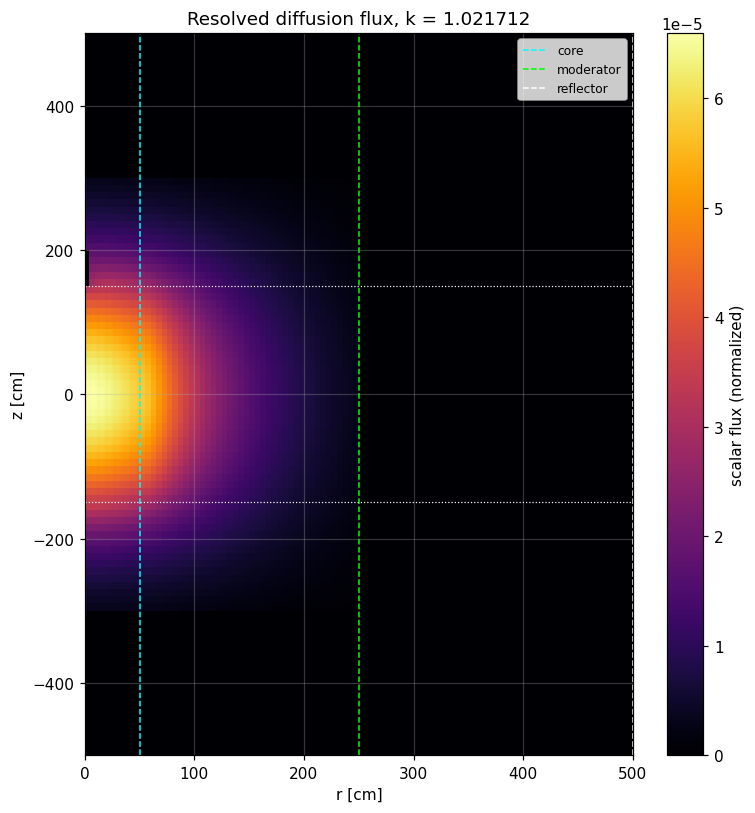

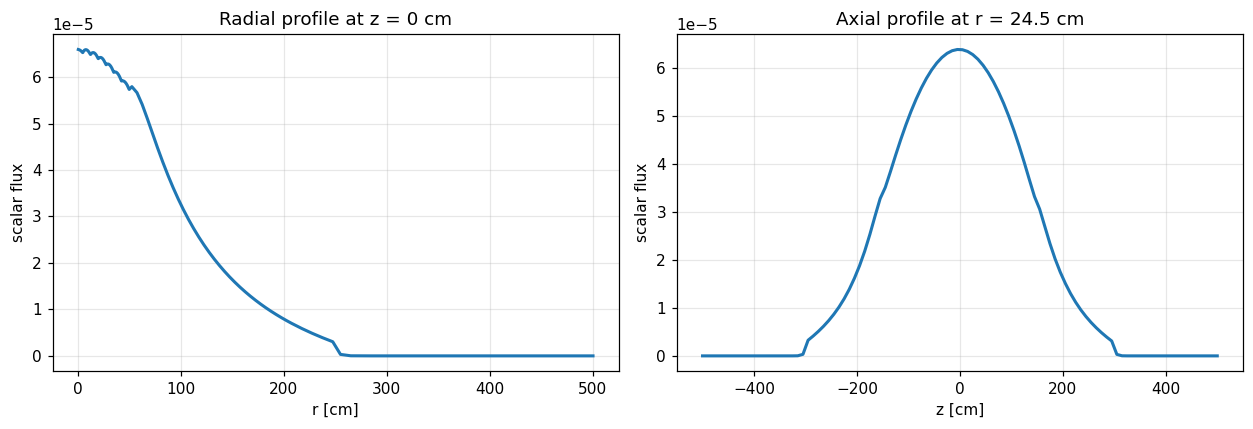

In [7]:
phi_clean = sol_clean['phi']
r_grid = sol_clean['r_grid']
z_grid = sol_clean['z_grid']

fig, ax = plt.subplots(figsize=(7.2, 7.5))
image = ax.pcolormesh(
    sol_clean['r_edges'],
    sol_clean['z_edges'],
    phi_clean.T,
    cmap='inferno',
    shading='flat',
)
for radius, color, label in (
    (geometry['core_radius_cm'], 'cyan', 'core'),
    (geometry['moderator_radius_cm'], 'lime', 'moderator'),
    (geometry['reflector_radius_cm'], 'white', 'reflector'),
):
    ax.axvline(radius, color=color, lw=1.0, ls='--', label=label)
ax.axhline(model_2d.core_height / 2, color='white', lw=0.8, ls=':')
ax.axhline(-model_2d.core_height / 2, color='white', lw=0.8, ls=':')
fig.colorbar(image, ax=ax, label='scalar flux (normalized)')
ax.set(xlabel='r [cm]', ylabel='z [cm]', title=f'Resolved diffusion flux, k = {k_diff:.6f}')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

midplane = int(np.argmin(np.abs(z_grid)))
probe = int(np.argmin(np.abs(r_grid - 0.5 * geometry['core_radius_cm'])))
fig, (ax_r, ax_z) = plt.subplots(1, 2, figsize=(11.5, 4.0))
ax_r.plot(r_grid, phi_clean[:, midplane], lw=2)
ax_r.set(xlabel='r [cm]', ylabel='scalar flux', title='Radial profile at z = 0 cm')
ax_z.plot(z_grid, phi_clean[probe, :], lw=2)
ax_z.set(xlabel='z [cm]', ylabel='scalar flux', title=f'Axial profile at r = {r_grid[probe]:.1f} cm')
plt.tight_layout()
plt.show()

## 3. Exploratory Equivalent Rod Scan

This calculation adds a scalar absorption increment inside the physical rod radius. It does not use rodded OpenMC MGXS, SPH factors, or a transport calibration, and is excluded from the clean-core acceptance criteria.

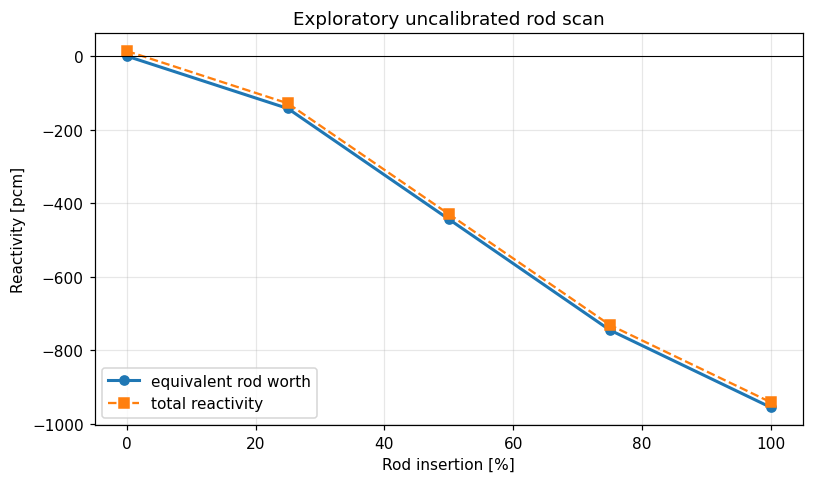

=== EXPLORATORY ROD SCAN ===
Not transport-calibrated; excluded from validation.
Full-insertion equivalent worth = -955.2 pcm
Full-insertion total rho        = -941.3 pcm


In [27]:
scan = scan_multigroup_rod_worth_2d(
    model_2d,
    x_values=np.linspace(0.0, 1.0, 5),
    mesh=mesh,
    clean_solution=sol_clean,
    max_iter=CACHE_SETTINGS.max_iter,
    tol=CACHE_SETTINGS.tol,
    source_tol=CACHE_SETTINGS.source_tol,
    max_inner_iter=CACHE_SETTINGS.max_inner_iter,
    inner_tol=CACHE_SETTINGS.inner_tol,
    warm_start=True,
)
if not np.isclose(scan['k_eff'][0], k_diff, rtol=0.0, atol=5.0e-5):
    raise RuntimeError('Rod scan zero-insertion state differs from the clean solve')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(scan['x_insert'] * 100, scan['delta_rho_pcm'], 'o-', lw=2, label='equivalent rod worth')
ax.plot(scan['x_insert'] * 100, scan['rho_total_pcm'], 's--', lw=1.5, label='total reactivity')
ax.axhline(0.0, color='black', lw=0.7)
ax.set(xlabel='Rod insertion [%]', ylabel='Reactivity [pcm]', title='Exploratory uncalibrated rod scan')
ax.legend()
plt.tight_layout()
plt.show()

print("=== EXPLORATORY ROD SCAN ===")
print("Not transport-calibrated; excluded from validation.")
print(f"Full-insertion equivalent worth = {scan['delta_rho_pcm'][-1]:+.1f} pcm")
print(f"Full-insertion total rho        = {scan['rho_total_pcm'][-1]:+.1f} pcm")

## 4. Interpretation

This workflow now has one production path: resolved XML regions, selectable group count, transport-derived diffusion coefficients, uncorrected non-`nu` P0 scattering, per-group sparse spatial operators, and a persistent prepared cache.

The next physics milestone is to document group-count and mesh trends and verify the uncorrected clean solution. SPH or discontinuity factors should only be introduced after that baseline is stable; the exploratory rod model requires rodded MGXS before it can become a validation target.